# 🛍️ E-commerce Sales Analytics

## 📌 Project Overview

This project analyzes e-commerce sales data to understand sales performance, customer behavior, product trends, and business opportunities using Python and data analytics.

## 🎯 Objectives

- Analyze overall sales and revenue performance
- Identify top-performing products and categories
- Analyze customer purchasing behavior
- Identify sales trends over time
- Generate actionable business insights

## 🛠️ Tools & Technologies

- Python
- Pandas
- Matplotlib
- Jupyter Notebook
- Data Analysis
- Data Visualization

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
orders = pd.read_csv("olist_orders_dataset.csv")

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.shape

(99441, 8)

In [6]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [8]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [9]:
orders["order_id"].duplicated().sum()

0

In [10]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [11]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [12]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [13]:
orders["order_status"].value_counts(normalize=True).mul(100).round(2)

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

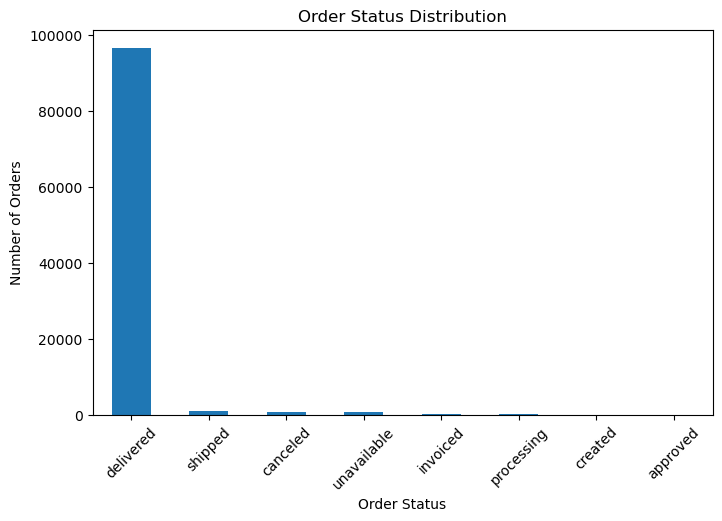

In [14]:
orders["order_status"].value_counts().plot(
    kind="bar",
    figsize=(8, 5),
    title="Order Status Distribution"
)

plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

### 💡 Insight

- **97.02% of orders were successfully delivered**, indicating a high overall order fulfillment rate.
- Canceled and unavailable orders together accounted for only **1.24%** of total orders.
- This suggests that most customers successfully completed their purchases and received their orders.

## 💰 Sales & Revenue Analysis

In [15]:
order_items = pd.read_csv("olist_order_items_dataset.csv")

In [16]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [17]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [18]:
total_revenue = order_items["price"].sum()

print("Total Revenue: ₹", round(total_revenue, 2))

Total Revenue: ₹ 13591643.7


In [19]:
total_orders = order_items["order_id"].nunique()

print("Total Orders:", total_orders)

Total Orders: 98666


In [20]:
average_order_value = total_revenue / total_orders

print("Average Order Value: ₹", round(average_order_value, 2))

Average Order Value: ₹ 137.75


In [21]:
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"])

In [22]:
sales_data = order_items.merge(
    orders[["order_id", "order_purchase_timestamp"]],
    on="order_id",
    how="left"
)

sales_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-14 14:33:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-08 10:00:35
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-04 13:57:51


In [23]:
sales_data["month"] = sales_data["order_purchase_timestamp"].dt.to_period("M")

monthly_revenue = sales_data.groupby("month")["price"].sum()

monthly_revenue

month
2016-09        267.36
2016-10      49507.66
2016-12         10.90
2017-01     120312.87
2017-02     247303.02
2017-03     374344.30
2017-04     359927.23
2017-05     506071.14
2017-06     433038.60
2017-07     498031.48
2017-08     573971.68
2017-09     624401.69
2017-10     664219.43
2017-11    1010271.37
2017-12     743914.17
2018-01     950030.36
2018-02     844178.71
2018-03     983213.44
2018-04     996647.75
2018-05     996517.68
2018-06     865124.31
2018-07     895507.22
2018-08     854686.33
2018-09        145.00
Freq: M, Name: price, dtype: float64

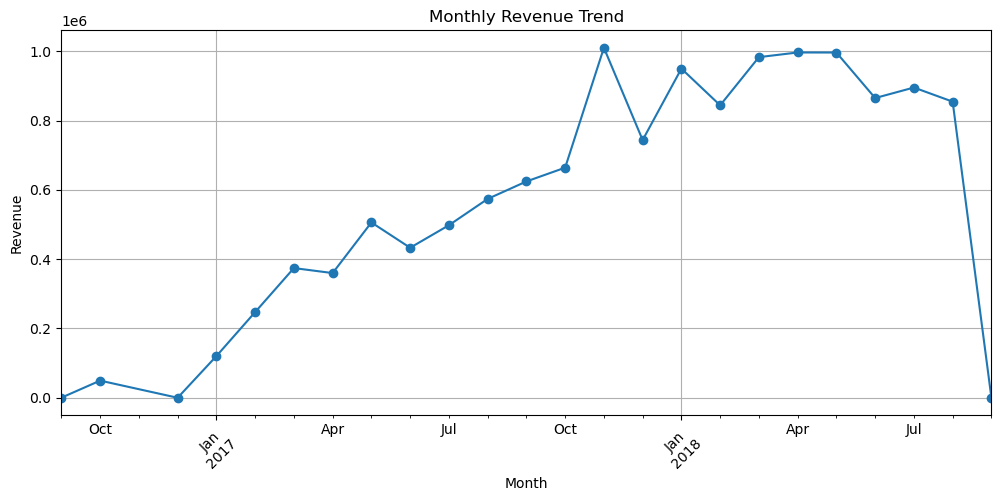

In [24]:
monthly_revenue.plot(
    kind="line",
    figsize=(12, 5),
    marker="o",
    title="Monthly Revenue Trend"
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### 💡 Insight

- Revenue showed a clear upward trend from early 2017 through 2018, indicating strong growth in e-commerce sales.
- **November 2017 recorded the highest monthly revenue**, exceeding ₹10 lakh.
- Revenue remained relatively strong throughout 2018, generally staying between ₹8.5 lakh and ₹10 lakh per month.
- The very low revenue values in September 2016 and September 2018 indicate that these periods contain incomplete data and should not be treated as representative monthly performance.

In [25]:
order_totals = order_items.groupby("order_id")["price"].sum()

actual_aov = order_totals.mean()

print("Actual Average Order Value: ₹", round(actual_aov, 2))

Actual Average Order Value: ₹ 137.75


## 🛍️ Product & Category Analysis

In [26]:
products = pd.read_csv("olist_products_dataset.csv")

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [27]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [28]:
category_translation = pd.read_csv("product_category_name_translation.csv")

category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [29]:
products = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [30]:
sales_data = sales_data.merge(
    products[["product_id", "product_category_name_english"]],
    on="product_id",
    how="left"
)

sales_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_purchase_timestamp,month,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-13 08:59:02,2017-09,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-04-26 10:53:06,2017-04,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-14 14:33:31,2018-01,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-08 10:00:35,2018-08,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-04 13:57:51,2017-02,garden_tools


In [31]:
category_revenue = (
    sales_data.groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue.head(10)

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

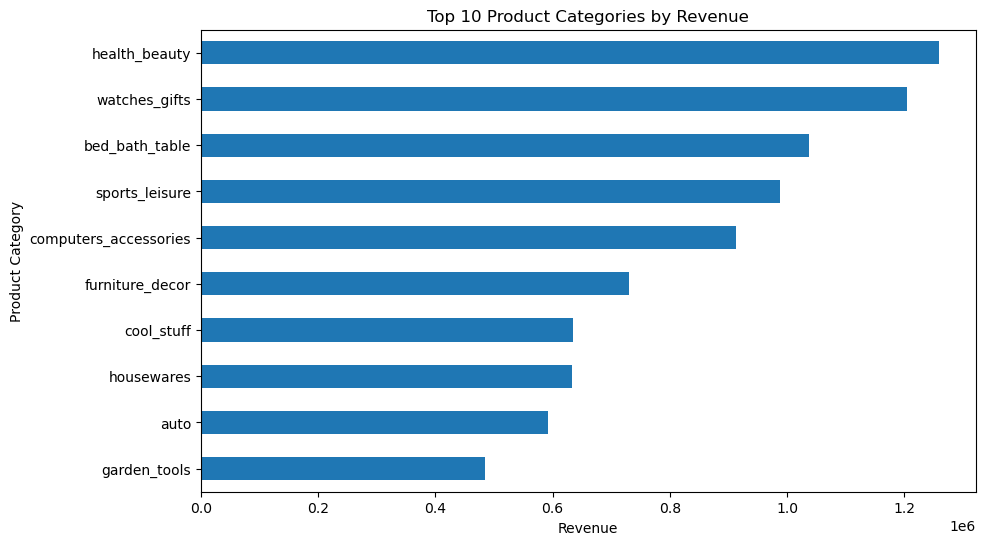

In [32]:
category_revenue.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Product Categories by Revenue"
)

plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.show()

### 💡 Insight

- **Health & Beauty** generated the highest revenue among all product categories, with approximately **₹12.59 lakh** in sales.
- **Watches & Gifts** ranked second, generating approximately **₹12.05 lakh**.
- **Bed, Bath & Table** ranked third with approximately **₹10.37 lakh**.
- Sports & Leisure and Computers & Accessories also showed strong revenue performance.
- The results indicate that **health, lifestyle, home, and technology-related categories are major revenue contributors**.

## 👥 Customer Analysis

In [33]:
customers = pd.read_csv("olist_customers_dataset.csv")

customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [34]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [35]:
customer_orders = orders.merge(
    customers[["customer_id", "customer_unique_id", "customer_city", "customer_state"]],
    on="customer_id",
    how="left"
)

customer_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP


In [36]:
unique_customers = customer_orders["customer_unique_id"].nunique()

print("Unique Customers:", unique_customers)

Unique Customers: 96096


In [37]:
orders_per_customer = (
    customer_orders.groupby("customer_unique_id")["order_id"]
    .nunique()
)

repeat_customers = (orders_per_customer > 1).sum()

print("Repeat Customers:", repeat_customers)

Repeat Customers: 2997


In [38]:
repeat_customer_percentage = (
    repeat_customers / unique_customers * 100
)

print("Repeat Customer Percentage:", round(repeat_customer_percentage, 2), "%")

Repeat Customer Percentage: 3.12 %


In [39]:
customer_spending = (
    sales_data.groupby("order_id")["price"]
    .sum()
    .reset_index()
)

customer_spending = customer_orders[
    ["order_id", "customer_unique_id"]
].merge(
    customer_spending,
    on="order_id",
    how="left"
)

customer_spending.head()

,order_id,customer_unique_id,price
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,19.90


In [40]:
customer_total_spending = (
    customer_spending.groupby("customer_unique_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

customer_total_spending.head(10)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13440.0
da122df9eeddfedc1dc1f5349a1a690c     7388.0
763c8b1c9c68a0229c42c9fc6f662b93     7160.0
dc4802a71eae9be1dd28f5d788ceb526     6735.0
459bef486812aa25204be022145caa62     6729.0
ff4159b92c40ebe40454e3e6a7c35ed6     6499.0
4007669dec559734d6f53e029e360987     5934.6
eebb5dda148d3893cdaf5b5ca3040ccb     4690.0
5d0a2980b292d049061542014e8960bf     4599.9
48e1ac109decbb87765a3eade6854098     4590.0
Name: price, dtype: float64

In [41]:
print("Average Customer Spending: ₹", 
      round(customer_total_spending.mean(), 2))

print("Median Customer Spending: ₹", 
      round(customer_total_spending.median(), 2))

Average Customer Spending: ₹ 141.44
Median Customer Spending: ₹ 89.0


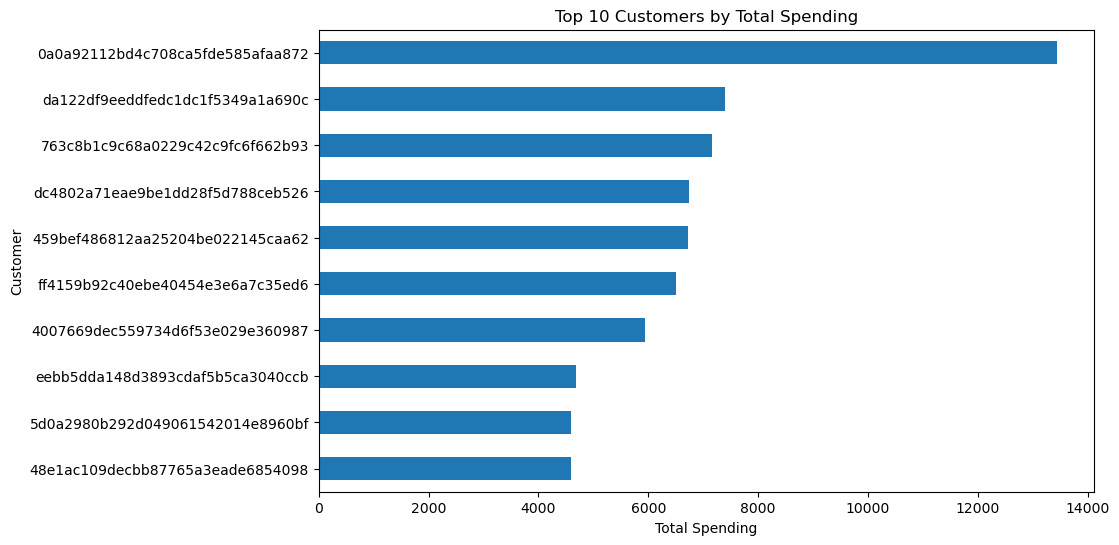

In [42]:
customer_total_spending.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Customers by Total Spending"
)

plt.xlabel("Total Spending")
plt.ylabel("Customer")
plt.show()

### 💡 Insight

- The average customer spending was **₹141.44**, while the median spending was **₹89.00**.
- The difference between the mean and median indicates that a relatively small number of high-value customers contribute significantly to overall revenue.
- The highest-spending customer generated **₹13,440** in purchases.
- With only **3.12% of customers making repeat purchases**, there is a significant opportunity to improve customer retention and encourage repeat purchases.

## 💳 Payment Method Analysis

In [45]:
payments = pd.read_csv("olist_order_payments_dataset.csv")

payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [46]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [47]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [48]:
payment_percentage = (
    payments["payment_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

payment_percentage

payment_type
credit_card    73.92
boleto         19.04
voucher         5.56
debit_card      1.47
not_defined     0.00
Name: proportion, dtype: float64

In [49]:
payment_revenue = (
    payments.groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

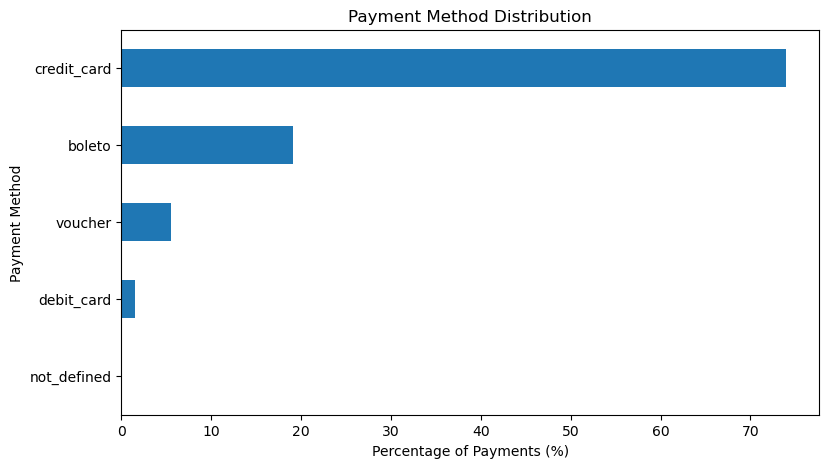

In [50]:
payment_percentage.sort_values().plot(
    kind="barh",
    figsize=(9, 5),
    title="Payment Method Distribution"
)

plt.xlabel("Percentage of Payments (%)")
plt.ylabel("Payment Method")
plt.show()

### 💡 Insight

- **Credit card** was the dominant payment method, accounting for **73.92%** of all payment records and approximately **₹1.25 crore** in payment value.
- **Boleto** was the second most-used method at **19.04%**, contributing approximately **₹28.69 lakh**.
- Voucher and debit card payments represented much smaller shares.
- The strong preference for credit cards suggests that supporting **smooth card payments and installment options** is important for the business.

In [53]:
payment_revenue = (
    payments.groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

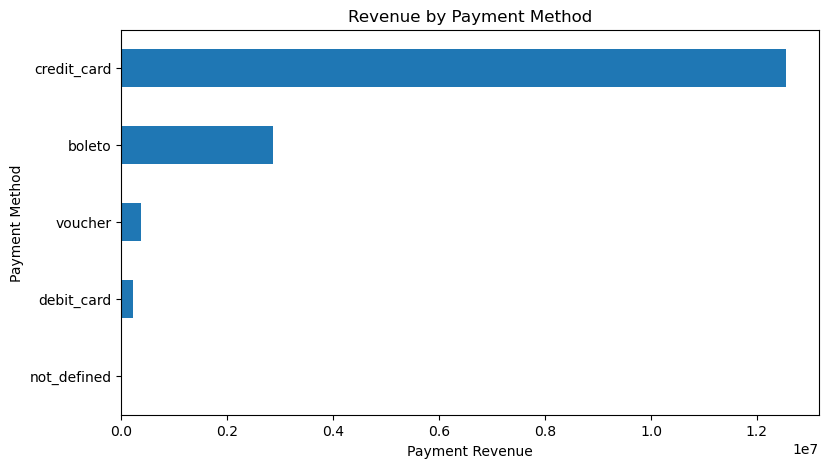

In [54]:
payment_revenue.sort_values().plot(
    kind="barh",
    figsize=(9, 5),
    title="Revenue by Payment Method"
)

plt.xlabel("Payment Revenue")
plt.ylabel("Payment Method")
plt.show()

### 💡 Insight

- **Credit card payments generated the highest payment value**, contributing approximately **₹1.25 crore**.
- **Boleto** generated approximately **₹28.69 lakh**, making it the second-largest payment method by revenue.
- The revenue distribution closely follows the payment usage pattern, showing that credit cards are both the most frequently used and the largest revenue-generating payment method.
- The business should continue prioritizing **reliable credit card processing and installment-based payment options** to support customer purchasing behavior.

## 📍 Geographic Analysis

In [56]:
state_orders = (
    customer_orders.groupby("customer_state")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

state_orders.head(10)


customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: order_id, dtype: int64

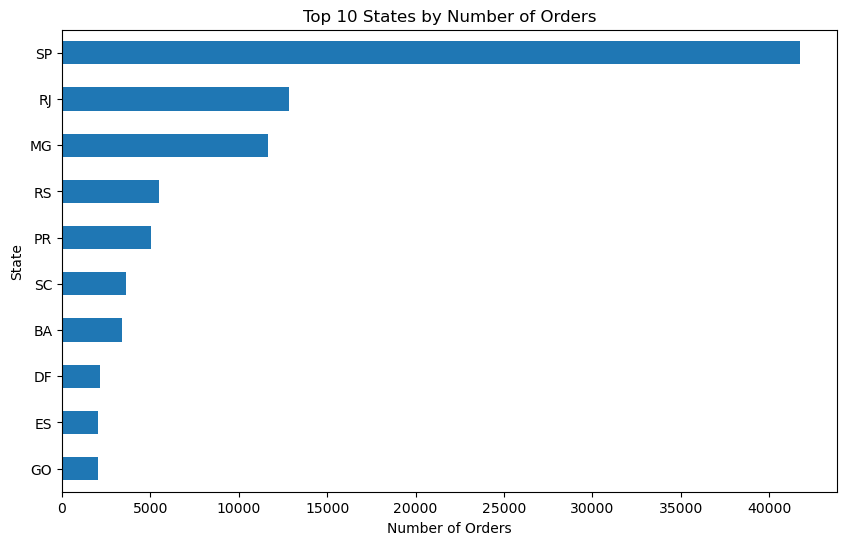

In [57]:
state_orders.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 States by Number of Orders"
)

plt.xlabel("Number of Orders")
plt.ylabel("State")
plt.show()

### 💡 Insight

- **São Paulo (SP)** recorded the highest number of orders with **41,746 orders**, significantly higher than other states.
- **Rio de Janeiro (RJ)** ranked second with **12,852 orders**, followed by **Minas Gerais (MG)** with **11,635 orders**.
- The top three states alone account for a large portion of total orders, showing that customer demand is highly concentrated in these regions.
- This suggests that São Paulo, Rio de Janeiro, and Minas Gerais are **key markets** where the business can focus its marketing, logistics, and customer acquisition strategies.

In [58]:
state_revenue = (
    sales_data.merge(
        customer_orders[["order_id", "customer_state"]],
        on="order_id",
        how="left"
    )
    .groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
)

state_revenue.head(10)

customer_state
SP    5202955.05
RJ    1824092.67
MG    1585308.03
RS     750304.02
PR     683083.76
SC     520553.34
BA     511349.99
DF     302603.94
GO     294591.95
ES     275037.31
Name: price, dtype: float64

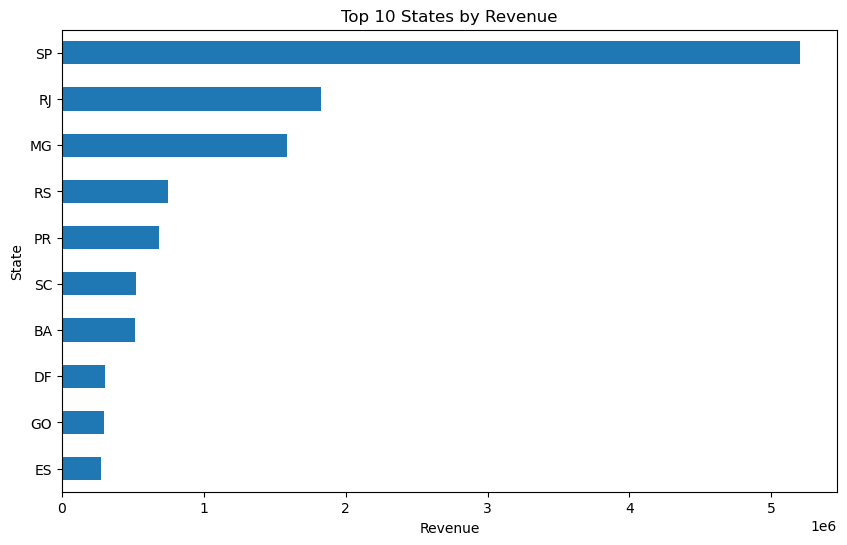

In [59]:
state_revenue.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 States by Revenue"
)

plt.xlabel("Revenue")
plt.ylabel("State")
plt.show()

### 💡 Insight

- **São Paulo (SP)** generated the highest revenue of approximately **₹52.03 lakh**, making it the strongest market in the dataset.
- **Rio de Janeiro (RJ)** ranked second with approximately **₹18.24 lakh**, followed by **Minas Gerais (MG)** with approximately **₹15.85 lakh**.
- The revenue ranking closely matches the order ranking, indicating that states with higher order volumes also contribute significantly to overall revenue.
- These high-performing states represent **key markets** where the business can prioritize marketing campaigns, inventory planning, and delivery infrastructure.

In [61]:
state_aov = (
    sales_data.merge(
        customer_orders[["order_id", "customer_state"]],
        on="order_id",
        how="left"
    )
    .groupby(["customer_state", "order_id"])["price"]
    .sum()
    .groupby("customer_state")
    .mean()
    .sort_values(ascending=False)
)

state_aov.head(10)

customer_state
PB    216.669323
AP    198.151471
AC    197.320370
AL    195.413163
RO    186.804211
PA    184.482278
TO    177.855699
PI    176.296308
MT    173.259723
RN    172.271743
Name: price, dtype: float64

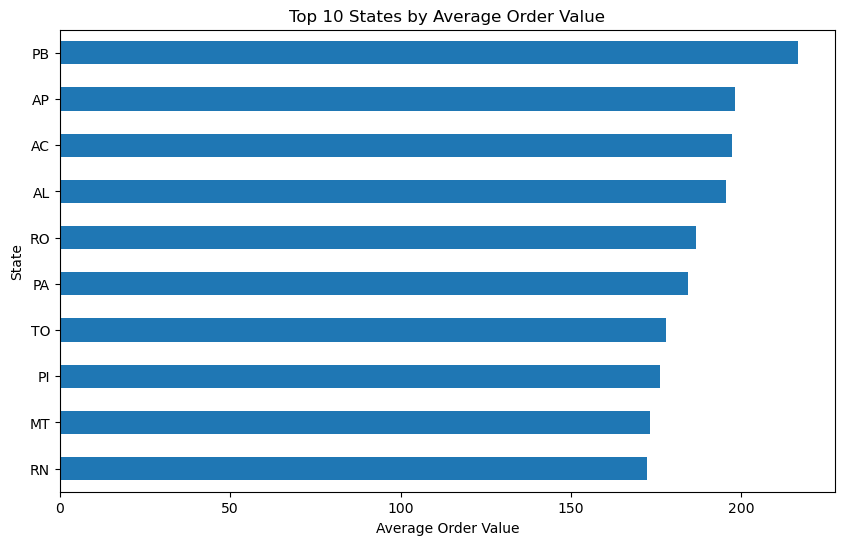

In [62]:
state_aov.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 States by Average Order Value"
)

plt.xlabel("Average Order Value")
plt.ylabel("State")
plt.show()

### 💡 Insight

- **Paraíba (PB)** had the highest average order value at approximately **₹216.67 per order**.
- **Amapá (AP)** and **Acre (AC)** followed with average order values of approximately **₹198.15** and **₹197.32**, respectively.
- Interestingly, the states with the highest AOV are not the same as the states with the highest total order volume.
- This indicates that **smaller markets can still have higher-value orders**, creating opportunities for targeted marketing and premium product strategies.

## 🚚 Delivery Performance Analysis

In [63]:
delivery_data = orders[
    [
        "order_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

delivery_data["delivery_days"] = (
    delivery_data["order_delivered_customer_date"]
    - delivery_data["order_purchase_timestamp"]
).dt.days

delivery_data["estimated_days"] = (
    delivery_data["order_estimated_delivery_date"]
    - delivery_data["order_purchase_timestamp"]
).dt.days

delivery_data.head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,estimated_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.0,15
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.0,19
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.0,26
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.0,26
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.0,12


In [64]:
average_delivery_days = delivery_data["delivery_days"].mean()
median_delivery_days = delivery_data["delivery_days"].median()

print("Average Delivery Time:", round(average_delivery_days, 2), "days")
print("Median Delivery Time:", round(median_delivery_days, 2), "days")

Average Delivery Time: 12.09 days
Median Delivery Time: 10.0 days


In [65]:
delivery_data["delivery_performance"] = (
    delivery_data["delivery_days"]
    <= delivery_data["estimated_days"]
)

on_time_percentage = (
    delivery_data["delivery_performance"]
    .mean() * 100
)

print("Orders Delivered On Time:", round(on_time_percentage, 2), "%")

Orders Delivered On Time: 89.67 %


In [67]:
delivery_status = (
    delivery_data["delivery_performance"]
    .value_counts()
    .rename({True: "On Time", False: "Late"})
)

delivery_status

delivery_performance
On Time    89168
Late       10273
Name: count, dtype: int64

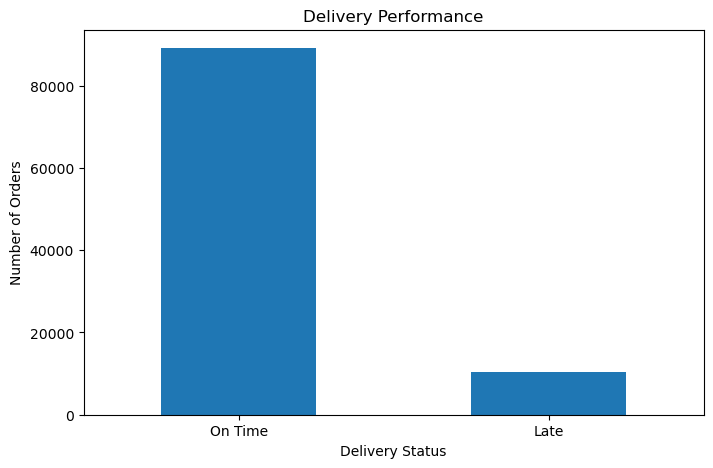

In [68]:
delivery_status.plot(
    kind="bar",
    figsize=(8, 5),
    title="Delivery Performance"
)

plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

### 💡 Insight

- The average delivery time was **12.09 days**, while the median delivery time was **10 days**.
- **89.67% of orders were delivered on or before the estimated delivery date**, indicating strong overall delivery performance.
- However, approximately **10.33% of orders were delivered later than the estimated date**, highlighting an opportunity to improve logistics and delivery reliability.
- Reducing late deliveries could improve **customer satisfaction and overall shopping experience**.

In [70]:
delivery_data["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

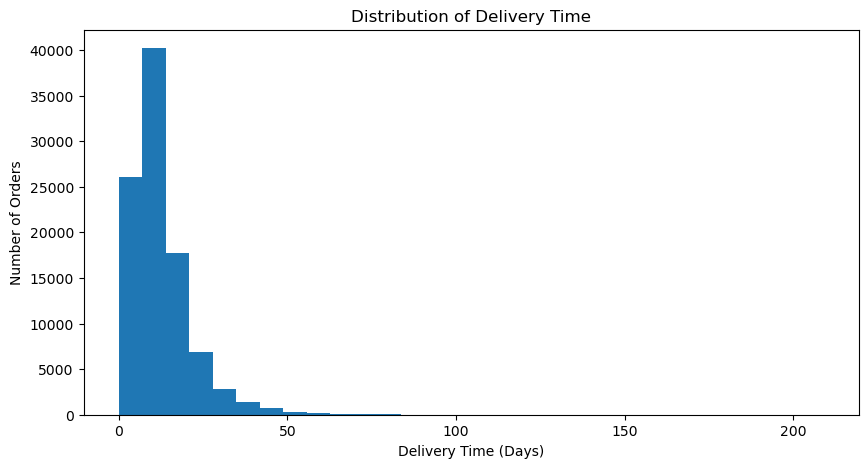

In [72]:
delivery_data["delivery_days"].plot(
    kind="hist",
    bins=30,
    figsize=(10, 5),
    title="Distribution of Delivery Time"
)

plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.show()

### 💡 Insight

- The average delivery time was **12.09 days**, while the median delivery time was **10 days**.
- **75% of orders were delivered within 15 days**, indicating that most customers received their orders within a relatively reasonable timeframe.
- The maximum delivery time was **209 days**, showing that a small number of orders experienced extremely long delivery delays.
- The large difference between the typical delivery time and the maximum value suggests the presence of **outlier delivery cases** that may require further investigation.

In [73]:
average_actual = delivery_data["delivery_days"].mean()
average_estimated = delivery_data["estimated_days"].mean()

print("Average Actual Delivery:", round(average_actual, 2), "days")
print("Average Estimated Delivery:", round(average_estimated, 2), "days")

Average Actual Delivery: 12.09 days
Average Estimated Delivery: 23.4 days


### 💡 Insight

- The average actual delivery time was **12.09 days**, compared with an average estimated delivery time of **23.40 days**.
- On average, orders were delivered approximately **11.31 days earlier than the estimated delivery date**.
- This indicates that the business generally **outperformed its estimated delivery timelines**, which can contribute positively to customer satisfaction.
- However, the earlier analysis showed that **10.33% of orders were still delivered late**, indicating that some individual orders experienced delivery delays.

In [74]:
state_delivery = (
    delivery_data.merge(
        customer_orders[["order_id", "customer_state"]],
        on="order_id",
        how="left"
    )
)

state_late_rate = (
    state_delivery.groupby("customer_state")["delivery_performance"]
    .apply(lambda x: (~x).mean() * 100)
    .sort_values(ascending=False)
)

state_late_rate.head(10)

customer_state
AL    25.907990
MA    22.088353
RR    21.739130
SE    18.857143
CE    18.488024
PI    18.383838
BA    16.390533
RJ    16.285403
PA    14.769231
TO    14.285714
Name: delivery_performance, dtype: float64

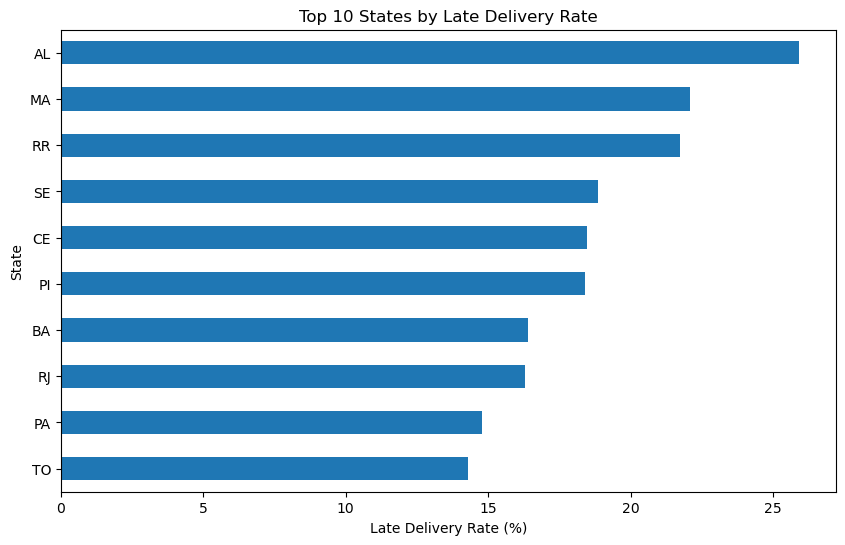

In [75]:
state_late_rate.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 States by Late Delivery Rate"
)

plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("State")
plt.show()

### 💡 Insight

- **Alagoas (AL)** had the highest late delivery rate at approximately **25.91%**.
- **Maranhão (MA)** and **Roraima (RR)** followed with late delivery rates of approximately **22.09%** and **21.74%**.
- Several states had late delivery rates above **18%**, indicating that delivery reliability varies significantly across regions.
- These regions may require **better logistics planning, carrier performance monitoring, and delivery infrastructure** to reduce delays.

## ⭐ Customer Reviews & Satisfaction

In [4]:

reviews = pd.read_csv("olist_order_reviews_dataset.csv")

reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [5]:
average_review_score = reviews["review_score"].mean()

print("Average Review Score:", round(average_review_score, 2), "/ 5")

Average Review Score: 4.09 / 5


In [8]:
review_distribution = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

review_distribution

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

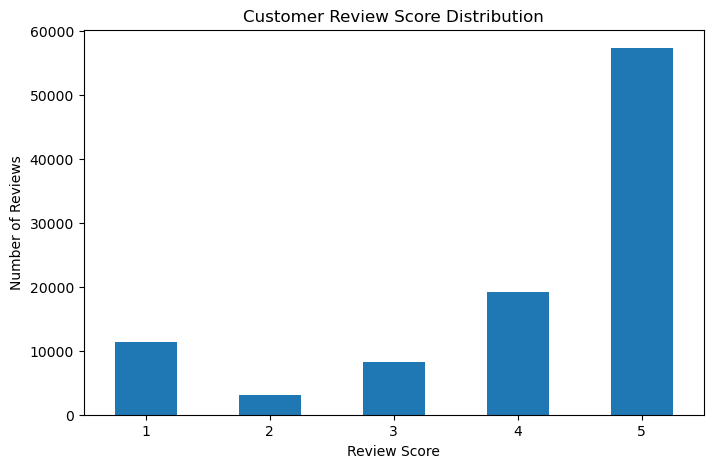

In [9]:
review_distribution.plot(
    kind="bar",
    figsize=(8, 5),
    title="Customer Review Score Distribution"
)

plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

NameError: name 'delivery_data' is not defined

### 💡 Insight

- The average customer review score was **4.09 out of 5**, indicating an overall positive customer experience.
- **5-star reviews were the most common**, with **57,328 reviews**, showing that a large proportion of customers were highly satisfied.
- **4-star reviews** were the second most common with **19,142 reviews**.
- Lower ratings were less frequent, although **11,424 customers gave a 1-star rating**, highlighting that some customers still experienced significant dissatisfaction.
- Overall, the high proportion of 4- and 5-star reviews suggests that **customer satisfaction is generally strong**, while low-rated reviews can be studied to identify areas for service improvement.

In [13]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_estimated_delivery_date",
    "order_delivered_customer_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

delivery_data = orders[
    [
        "order_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

delivery_data["delivery_days"] = (
    delivery_data["order_delivered_customer_date"]
    - delivery_data["order_purchase_timestamp"]
).dt.days

delivery_data["estimated_days"] = (
    delivery_data["order_estimated_delivery_date"]
    - delivery_data["order_purchase_timestamp"]
).dt.days

delivery_data["delivery_performance"] = (
    delivery_data["delivery_days"]
    <= delivery_data["estimated_days"]
)

print("Delivery data created successfully!")

Delivery data created successfully!


In [14]:
review_delivery = reviews[["order_id", "review_score"]].merge(
    delivery_data[["order_id", "delivery_performance"]],
    on="order_id",
    how="inner"
)

review_delivery.groupby("delivery_performance")["review_score"].mean()

delivery_performance
False    2.261419
True     4.292077
Name: review_score, dtype: float64

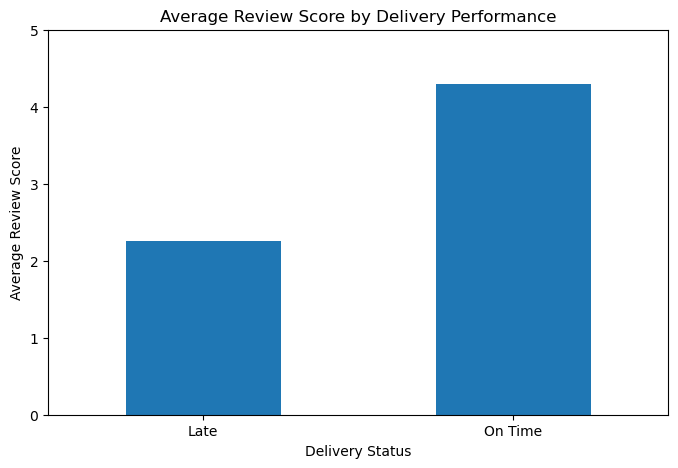

In [15]:
review_delivery["delivery_status"] = (
    review_delivery["delivery_performance"]
    .map({True: "On Time", False: "Late"})
)

review_scores_by_delivery = (
    review_delivery.groupby("delivery_status")["review_score"]
    .mean()
)

review_scores_by_delivery.plot(
    kind="bar",
    figsize=(8, 5),
    title="Average Review Score by Delivery Performance"
)

plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.show()

### 💡 Insight

- Customers whose orders were delivered **on time** gave an average review score of **4.29 out of 5**.
- Customers whose orders were delivered **late** gave a much lower average score of **2.26 out of 5**.
- This shows a strong relationship between **delivery performance and customer satisfaction**.
- Late deliveries can significantly affect the overall customer experience and may lead to lower ratings.
- Therefore, improving delivery reliability should be a key business priority for increasing **customer satisfaction and positive reviews**.

## 🏪 Seller Performance Analysis

In [16]:
sellers = pd.read_csv("olist_sellers_dataset.csv")

sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [18]:
order_items = pd.read_csv("olist_order_items_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

sales_data = order_items.merge(
    orders[["order_id", "order_purchase_timestamp"]],
    on="order_id",
    how="left"
)

seller_performance = (
    sales_data.groupby("seller_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("price", "sum")
    )
    .sort_values("total_revenue", ascending=False)
)

seller_performance.head(10)

,total_orders,total_revenue
seller_id,,
4869f7a5dfa277a7dca6462dcf3b52b2,1132,229472.63
53243585a1d6dc2643021fd1853d8905,358,222776.05
4a3ca9315b744ce9f8e9374361493884,1806,200472.92
fa1c13f2614d7b5c4749cbc52fecda94,585,194042.03
7c67e1448b00f6e969d365cea6b010ab,982,187923.89
7e93a43ef30c4f03f38b393420bc753a,336,176431.87
da8622b14eb17ae2831f4ac5b9dab84a,1314,160236.57
7a67c85e85bb2ce8582c35f2203ad736,1160,141745.53
1025f0e2d44d7041d6cf58b6550e0bfa,915,138968.55


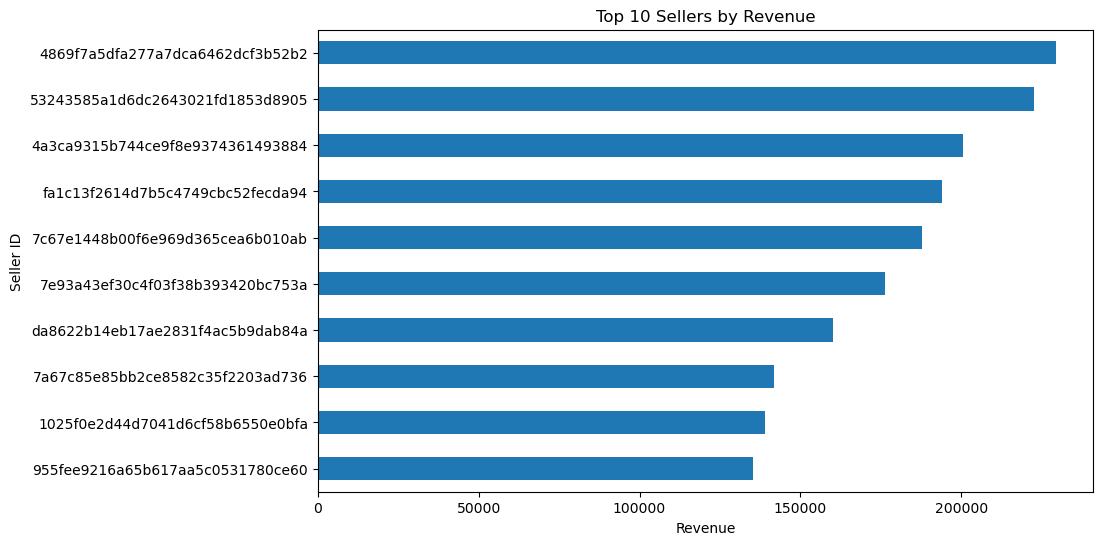

In [19]:
seller_performance.head(10)["total_revenue"].sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Sellers by Revenue"
)

plt.xlabel("Revenue")
plt.ylabel("Seller ID")
plt.show()

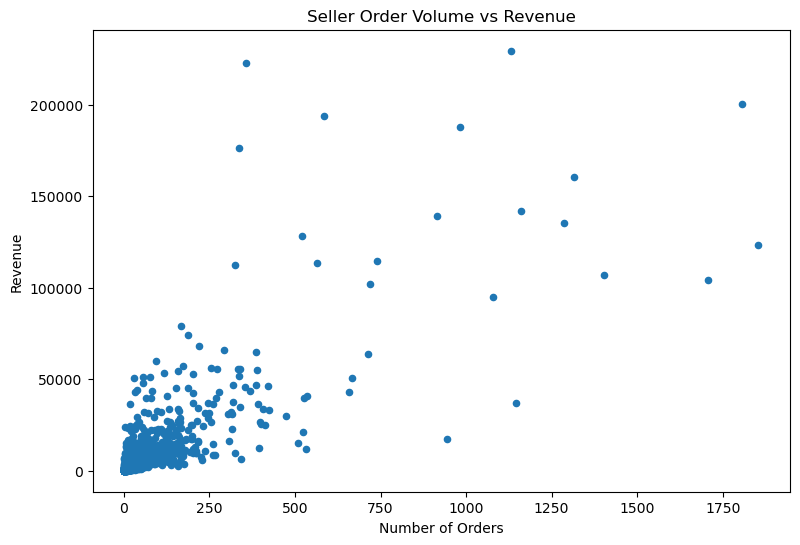

In [20]:
seller_performance.plot(
    kind="scatter",
    x="total_orders",
    y="total_revenue",
    figsize=(9, 6),
    title="Seller Order Volume vs Revenue"
)

plt.xlabel("Number of Orders")
plt.ylabel("Revenue")
plt.show()

In [21]:
top_sellers_orders = (
    seller_performance
    .sort_values("total_orders", ascending=False)
    .head(10)
)

top_sellers_orders

,total_orders,total_revenue
seller_id,,
6560211a19b47992c3666cc44a7e94c0,1854,123304.83
4a3ca9315b744ce9f8e9374361493884,1806,200472.92
cc419e0650a3c5ba77189a1882b7556a,1706,104288.42
1f50f920176fa81dab994f9023523100,1404,106939.21
da8622b14eb17ae2831f4ac5b9dab84a,1314,160236.57
955fee9216a65b617aa5c0531780ce60,1287,135171.70
7a67c85e85bb2ce8582c35f2203ad736,1160,141745.53
ea8482cd71df3c1969d7b9473ff13abc,1146,37177.52
4869f7a5dfa277a7dca6462dcf3b52b2,1132,229472.63


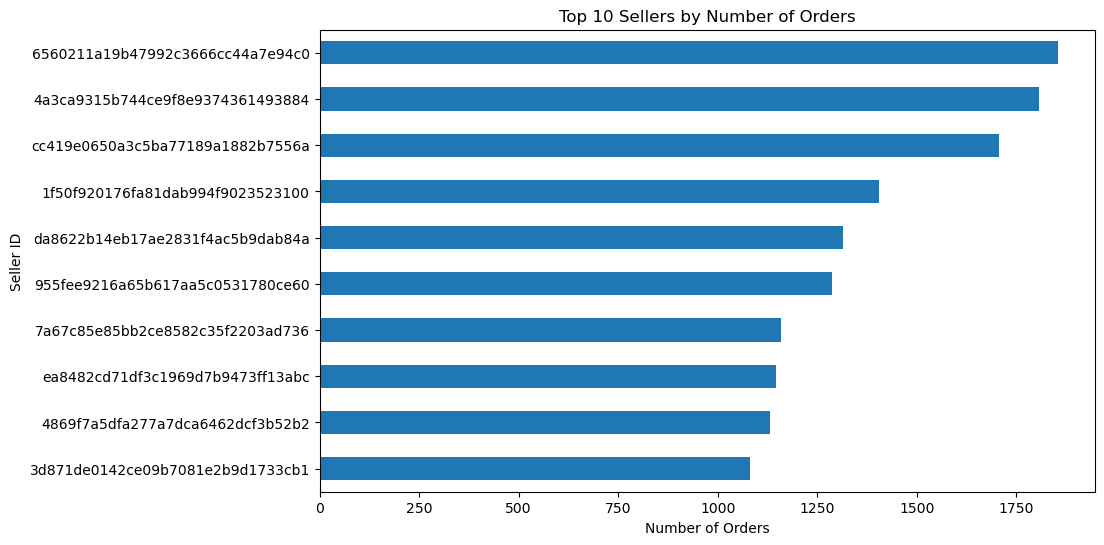

In [22]:
top_sellers_orders["total_orders"].sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Sellers by Number of Orders"
)

plt.xlabel("Number of Orders")
plt.ylabel("Seller ID")
plt.show()

In [23]:
seller_performance["average_order_value"] = (
    seller_performance["total_revenue"]
    / seller_performance["total_orders"]
)

seller_performance.sort_values(
    "average_order_value",
    ascending=False
).head(10)

,total_orders,total_revenue,average_order_value
seller_id,,,
80ceebb4ee9b31afb6c6a916a574a1e2,1,6729.00,6729.000000
ee27a8f15b1dded4d213a468ba4eb391,1,6499.00,6499.000000
b37c4c02bda3161a7546a4e6d222d5b2,4,24075.00,6018.750000
585175ec331ea177fa47199e39a6170a,1,3549.00,3549.000000
abe021b01ba992245271b9aa422032df,2,6720.00,3360.000000
a00824eb9093d40e589b940ec45c4eb0,3,9399.97,3133.323333
e2a1ac9bf33e5549a2a4f834e70df2f8,5,14999.45,2999.890000
e908c0f3646e8b60375734a350d95d71,1,2951.00,2951.000000
d63c73efd41eb002280e7ec831424edb,2,5598.00,2799.000000


In [24]:
reliable_sellers = seller_performance[
    seller_performance["total_orders"] >= 10
].copy()

reliable_sellers.sort_values(
    "average_order_value",
    ascending=False
).head(10)

,total_orders,total_revenue,average_order_value
seller_id,,,
59417c56835dd8e2e72f91f809cd4092,18,36459.00,2025.500000
40db9e9aa57f7bb151bcda6b0f9bdbb7,12,23168.00,1930.666667
2bf6a2c1e71bbd29a4ad64e6d3c3629f,30,50628.90,1687.630000
c3acdfac4e3e97ff87529454fbc03642,12,16788.00,1399.000000
b1b3948701c5c72445495bd161b83a4c,18,24699.19,1372.177222
b839e41795b7f3ad94cc2014a52f6796,33,42829.00,1297.848485
f08a5b9dd6767129688d001acafc21e5,11,14069.63,1279.057273
ba90964cff9b9e0e6f32b23b82465f7b,38,44212.50,1163.486842
87b740daf17b5d1be335a64164ec6842,13,14699.87,1130.759231


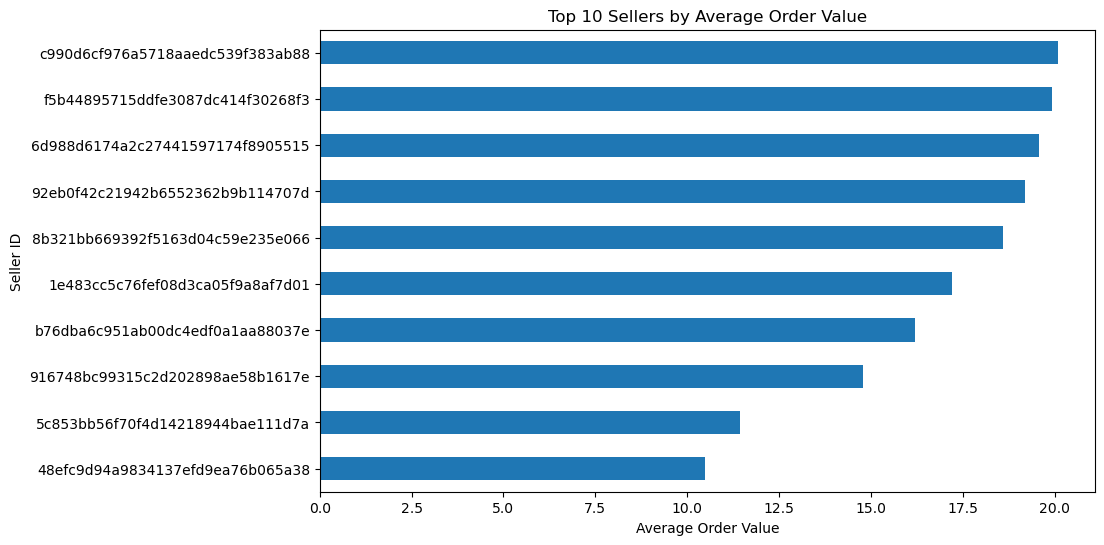

In [25]:
reliable_sellers.sort_values(
    "average_order_value"
).head(10)["average_order_value"].plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Sellers by Average Order Value"
)

plt.xlabel("Average Order Value")
plt.ylabel("Seller ID")
plt.show()

### 💡 Insight

- Sellers show significant differences in both **sales volume and average order value**.
- Some sellers generate high revenue through a large number of orders, while others achieve strong performance through **higher-value orders**.
- Among sellers with at least 10 orders, the highest average order value was approximately **₹2,025.50**.
- This indicates that seller performance should be evaluated using both **order volume and order value**, rather than revenue alone.
- The business can use these metrics to identify **high-performing sellers, understand product mix, and improve seller management strategies**.

In [28]:
# Reload datasets and recreate important project variables

orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

# Convert date columns
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_estimated_delivery_date",
    "order_delivered_customer_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

# Customer data
customer_orders = orders.merge(
    customers[
        ["customer_id", "customer_unique_id",
         "customer_city", "customer_state"]
    ],
    on="customer_id",
    how="left"
)

# Sales data
sales_data = order_items.merge(
    orders[["order_id", "order_purchase_timestamp"]],
    on="order_id",
    how="left"
)

# Delivery data
delivery_data = orders[
    [
        "order_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

delivery_data["delivery_days"] = (
    delivery_data["order_delivered_customer_date"]
    - delivery_data["order_purchase_timestamp"]
).dt.days

delivery_data["estimated_days"] = (
    delivery_data["order_estimated_delivery_date"]
    - delivery_data["order_purchase_timestamp"]
).dt.days

delivery_data["delivery_performance"] = (
    delivery_data["delivery_days"]
    <= delivery_data["estimated_days"]
)

print("Project variables recreated successfully! ✅")

Project variables recreated successfully! ✅


In [29]:
# Key Business KPIs

total_revenue = order_items["price"].sum()
total_orders = order_items["order_id"].nunique()

order_totals = order_items.groupby("order_id")["price"].sum()
actual_aov = order_totals.mean()

unique_customers = customer_orders["customer_unique_id"].nunique()

orders_per_customer = (
    customer_orders.groupby("customer_unique_id")["order_id"]
    .nunique()
)

repeat_customers = (orders_per_customer > 1).sum()

repeat_customer_percentage = (
    repeat_customers / unique_customers * 100
)

on_time_percentage = (
    delivery_data["delivery_performance"].mean() * 100
)

average_review_score = reviews["review_score"].mean()


print("Key Business KPIs")
print("-" * 30)

print("Total Revenue: ₹", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Average Order Value: ₹", round(actual_aov, 2))
print("Unique Customers:", unique_customers)
print("Repeat Customer Rate:", round(repeat_customer_percentage, 2), "%")
print("On-Time Delivery Rate:", round(on_time_percentage, 2), "%")
print("Average Review Score:", round(average_review_score, 2), "/ 5")

Key Business KPIs
------------------------------
Total Revenue: ₹ 13591643.7
Total Orders: 98666
Average Order Value: ₹ 137.75
Unique Customers: 96096
Repeat Customer Rate: 3.12 %
On-Time Delivery Rate: 89.67 %
Average Review Score: 4.09 / 5


## 💡 Key Business Insights

### 📈 Sales Performance
- The business generated approximately **₹1.36 crore in revenue** from **98,666 orders**.
- The average order value was approximately **₹137.75**.
- Revenue showed a strong growth trend through 2017 and 2018, with **November 2017 recording the highest monthly revenue**.

### 🛍️ Product Performance
- **Health & Beauty** was the highest-revenue product category.
- Watches & Gifts and Bed, Bath & Table were also major contributors.
- This indicates strong demand for **health, lifestyle, home, and technology-related products**.

### 👥 Customer Behavior
- The dataset contains **96,096 unique customers**.
- Only **3.12% of customers made repeat purchases**, indicating a major customer-retention opportunity.
- The difference between average and median customer spending suggests that a small number of high-value customers contribute significantly to revenue.

### 🚚 Delivery & Satisfaction
- **89.67% of orders were delivered on time**.
- The average delivery time was **12.09 days**.
- On-time deliveries received an average review score of **4.29**, compared with only **2.26 for late deliveries**.
- This demonstrates that delivery performance has a strong relationship with customer satisfaction.

### 💳 Payment Behavior
- **Credit cards accounted for 73.92% of payment records** and generated the highest payment value.
- Maintaining reliable card payment and installment options is therefore important for the business.

### 📍 Geographic Performance
- **São Paulo (SP)** was the strongest market by both order volume and revenue.
- Smaller states such as Paraíba showed higher average order values, indicating opportunities beyond the largest markets.

## 🎯 Business Recommendations

### 1. Improve Customer Retention
With only **3.12% of customers making repeat purchases**, the business should focus on retention strategies such as personalized offers, loyalty programs, and targeted email campaigns.

### 2. Focus on High-Performing Categories
Categories such as **Health & Beauty, Watches & Gifts, and Bed, Bath & Table** generate significant revenue. The business can prioritize inventory, promotions, and marketing for these categories.

### 3. Improve Delivery Reliability
Although **89.67% of orders were delivered on time**, late deliveries were associated with significantly lower customer ratings. The business should monitor carrier performance and improve logistics in regions with higher late-delivery rates.

### 4. Strengthen High-Value Markets
**São Paulo, Rio de Janeiro, and Minas Gerais** are major revenue-generating markets. These regions can receive greater focus for marketing, inventory planning, and delivery infrastructure.

### 5. Encourage Higher-Value Purchases
Since customer spending is concentrated among a smaller group of high-value customers, the business can use **product recommendations, bundles, and personalized promotions** to increase average order value.

### 6. Optimize Payment Experience
Credit cards are the dominant payment method. Maintaining a reliable checkout experience and offering flexible installment options can help support continued sales.

## 🏁 Final Conclusion

This project provided a comprehensive analysis of e-commerce sales performance, customer behavior, product categories, payment methods, geographic markets, seller performance, delivery efficiency, and customer satisfaction.

The analysis showed strong overall sales performance, with approximately **₹1.36 crore in revenue** generated from **98,666 orders**. However, the low **3.12% repeat customer rate** highlights a major opportunity to improve customer retention.

The analysis also identified **Health & Beauty** as the leading revenue-generating category and **São Paulo** as the strongest geographic market. Delivery performance was generally positive, with **89.67% of orders delivered on time**, while the strong difference in review scores between on-time and late deliveries demonstrated the importance of reliable logistics.

Overall, the project highlights how data analytics can help businesses identify growth opportunities, understand customer behavior, improve operational efficiency, and make data-driven business decisions.

# 📌 Project Summary

This project analyzes the Olist Brazilian E-Commerce dataset to understand sales performance, customer behavior, product trends, payment preferences, geographic performance, seller performance, delivery efficiency, and customer satisfaction.

The analysis uses Python and Pandas to transform raw e-commerce data into meaningful business insights and actionable recommendations.